# TechTrack use case 

# Task 4: Robustness analysis of augmentation impact
## Measure the effect on Model 2 of different augmentations: Gaussian blur, vertical Flips, and brightness adjustments

We evaluate our best model (Model 2) on:
1) **Original images** of the sampled subset of 5000 images (baseline)
2) **Gaussian blur** augmented images
3) **Vertical flip** augmented images
4) **Brightness/contrast** adjusted images

For each, we compute:
- overall **mAP** (11-point interpolation)
- per-class AP
- relative degradation vs baseline

**Important note:** When we augment an image geometrically (vertical flip), we must apply the **same transform** to the ground-truth boxes.
- Blur and brightness do **not** change box coordinates.
- Vertical flip changes box **y** coordinate (and therefore y-center in YOLO format).

In [3]:
# Imports
import os, glob, pickle
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **k: x

import sys
from pathlib import Path

TECHTRACK_DIR = Path.cwd().parent / "techtrack"
sys.path.insert(0, str(TECHTRACK_DIR))

from modules.inference.model import Detector
from modules.inference.nms import NMS
from modules.utils import metrics
from modules.rectification.augmentation import Augmenter


## 1) Paths and configuration

In [6]:
import os

REPO_ROOT = os.getcwd()

# Use the sampled subset folder
# (images + labels in SAME folder)
SAMPLED_SUBSET_DIR = os.path.join(REPO_ROOT, "analysis_cache_sampling", "sampled_subset")
# If you placed it elsewhere, change the path above.

DATASET_DIR = SAMPLED_SUBSET_DIR
assert os.path.isdir(DATASET_DIR), f"Sampled subset dir missing: {DATASET_DIR}"

# Model paths (unchanged)
MODELS_DIR = os.path.join(TECHTRACK_DIR, "storage", "yolo_models")

MODEL2_CFG = os.path.join(MODELS_DIR, "yolov4-tiny-logistics_size_416_2.cfg")
MODEL2_WEIGHTS = os.path.join(MODELS_DIR, "yolov4-tiny-logistics_size_416_2.weights")

# Names file: prefer the sampled subset dir
CLASS_NAMES_PATH = os.path.join(DATASET_DIR, "logistics.names")

assert os.path.exists(MODEL2_CFG) and os.path.exists(MODEL2_WEIGHTS), "Model 2 cfg/weights missing"
assert os.path.exists(CLASS_NAMES_PATH), f"logistics.names missing at {CLASS_NAMES_PATH}"
assert os.path.isdir(MODELS_DIR), "Models dir missing"

with open(CLASS_NAMES_PATH, "r") as f:
    CLASS_NAMES = [ln.strip() for ln in f if ln.strip()]
NUM_CLASSES = len(CLASS_NAMES)

# Inference thresholds (use your selected NMS threshold here)
SCORE_THRESHOLD = 0.5
NMS_IOU_THRESHOLD = 0.45

# Evaluation settings
MAP_IOU_THRESHOLD = 0.5
EVAL_TYPE = "class_scores"

# Robustness test settings
# Use a subset if you want faster iteration; set 0 for full dataset
LIMIT = 0

# Blur settings
BLUR_KERNEL = (7, 7)   # must be odd
BLUR_SIGMA = 0

# Brightness/contrast settings (OpenCV addWeighted style)
BRIGHT_ALPHA = 1.2
BRIGHT_BETA = 20

CACHE_DIR = os.path.join(REPO_ROOT, "cache_aug_robustness")
os.makedirs(CACHE_DIR, exist_ok=True)

print("DATASET_DIR:", DATASET_DIR)
print("MODELS_DIR :", MODELS_DIR)
print("NUM_CLASSES:", NUM_CLASSES)
print("CACHE_DIR  :", CACHE_DIR)


DATASET_DIR: C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\analysis\analysis_cache_sampling\sampled_subset
MODELS_DIR : C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\yolo_models
NUM_CLASSES: 20
CACHE_DIR  : C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\analysis\cache_aug_robustness


## 2) Dataset utilities (load pairs and parse YOLO labels)

In [5]:

def list_dataset_pairs(dataset_dir: str) -> List[Tuple[str, str]]:
    imgs = sorted(glob.glob(os.path.join(dataset_dir, "*.jpg")) + glob.glob(os.path.join(dataset_dir, "*.png")))
    lbls = sorted(glob.glob(os.path.join(dataset_dir, "*.txt")))
    lbl_map = {os.path.splitext(os.path.basename(p))[0]: p for p in lbls}
    pairs = []
    for img in imgs:
        stem = os.path.splitext(os.path.basename(img))[0]
        if stem in lbl_map:
            pairs.append((img, lbl_map[stem]))
    return pairs

def parse_yolo_label_file(label_path: str, img_w: int, img_h: int):
    boxes, classes = [], []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])
            # Assume normalized
            xc *= img_w; yc *= img_h; w *= img_w; h *= img_h
            x = int(xc - w/2.0); y = int(yc - h/2.0)
            boxes.append([x, y, int(w), int(h)])
            classes.append(cid)
    return boxes, classes

pairs = list_dataset_pairs(DATASET_DIR)
if LIMIT and LIMIT > 0:
    pairs = pairs[:LIMIT]
print("Pairs:", len(pairs))


Pairs: 5000


## 3) Ground-truth transform for vertical flip

When evaluating vertical flips, we must apply the same transformation not only to the image but also to its bounding boxes. Because our boxes are stored in top-left xywh pixel format, a vertical flip keeps $x$ and $w$ unchanged but maps the top-left $y$ coordinate to the mirrored position: $y' = H - (y + h)$, where $H$ is the image height. The helper function below performs this conversion for a list of boxes, ensuring ground-truth and predictions remain in the same coordinate system after flipping.

In [15]:

def flip_vertical_boxes_xywh(boxes_xywh: List[List[int]], img_h: int) -> List[List[int]]:
    flipped = []
    for x, y, w, h in boxes_xywh:
        new_y = int(img_h - (y + h))
        flipped.append([int(x), new_y, int(w), int(h)])
    return flipped


## 4) Evaluation helpers (mAP and per-class AP)

In [16]:

def ap_11_point(recall_points, precision_points):
    if len(recall_points) == 0 or len(precision_points) == 0:
        return 0.0
    pts = list(zip(recall_points, precision_points))
    vals = []
    for r_th in [i/10.0 for i in range(11)]:
        cand = [p for r, p in pts if r >= r_th]
        vals.append(max(cand) if cand else 0.0)
    return float(np.mean(vals))

def compute_map_and_ap(y_true, pred_scores, num_classes: int):
    precision, recall, thresholds = metrics.calculate_precision_recall_curve(
        y_true, pred_scores, num_classes=num_classes
    )
    ap = np.zeros((num_classes,), dtype=float)
    for c in range(num_classes):
        ap[c] = ap_11_point(recall[c], precision[c])
    return float(ap.mean()), ap


## 5) Run evaluation under augmentation conditions

We run the inference pipeline on augmented images and evaluate against appropriately transformed ground truth.

**Augmentation conditions**:
- `baseline`: original images
- `gaussian_blur`: apply Augmenter.gaussian_blur
- `vertical_flip`
- `brightness`: apply Augmenter.change_brightness

In [17]:

@dataclass
class EvalResult:
    """
    Stores evaluation results for a specific augmentation condition.

    Attributes:
        condition (str): Name of the condition (e.g., 'baseline', 'gaussian_blur').
        map_value (float): Mean Average Precision (mAP) over all classes.
        ap_per_class (np.ndarray): Per-class Average Precision values, shape (NUM_CLASSES,).
        mean_dets_per_img (float): Average number of detections per image after NMS.
    """
    condition: str
    map_value: float
    ap_per_class: np.ndarray
    mean_dets_per_img: float

def run_condition(condition: str, force: bool = False) -> EvalResult:
    """
    Evaluate model (MODEL2) on the dataset under a specific augmentation condition.

    Applies the specified augmentation to each image before inference, computes
    detections, and evaluates mAP and per-class AP. Results are cached to avoid
    recomputation.

    Args:
        condition (str): Name of the augmentation condition.
            Supported values: "baseline", "gaussian_blur", "vertical_flip", "brightness".
        force (bool, optional): If True, ignore cached results and recompute.

    Returns:
        EvalResult: Aggregated metrics for the condition.
    """
    # Define cache file path based on condition and dataset size
    cache_path = os.path.join(CACHE_DIR, f"model2_{condition}_limit{len(pairs)}.pkl")
    # Load from cache if available and not forced to recompute
    if (not force) and os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    # Initialize detector and NMS with fixed parameters (same for all conditions)
    detector = Detector(MODEL2_WEIGHTS, MODEL2_CFG, CLASS_NAMES_PATH, score_threshold=SCORE_THRESHOLD)
    nms = NMS(score_threshold=SCORE_THRESHOLD, nms_iou_threshold=NMS_IOU_THRESHOLD)

    # Containers for ground truth and predictions across all images
    gt_boxes_all, gt_classes_all = [], []
    pred_boxes_all, pred_classes_all, pred_scores_all, pred_cls_scores_all = [], [], [], []
    det_counts = []

    # Iterate over all image-label pairs
    for img_path, lbl_path in tqdm(pairs, desc=condition, total=len(pairs)):
        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]

        # Parse ground truth boxes and classes (original coordinates)
        gt_b, gt_c = parse_yolo_label_file(lbl_path, W, H)

        # Apply augmentation
        if condition == "baseline":
            aug_img = img
            aug_gt_b = gt_b

        elif condition == "gaussian_blur":
            # Apply Gaussian blur to the image
            aug_img = Augmenter.gaussian_blur(image=img, ksize=BLUR_KERNEL, sigma=BLUR_SIGMA)
            aug_gt_b = gt_b  # boxes unchanged

        elif condition == "vertical_flip":
            # Flip image vertically (upside-down)
            aug_img = cv2.flip(img, 0)  # vertical flip
            aug_gt_b = flip_vertical_boxes_xywh(gt_b, img_h=H)

        elif condition == "brightness":
            # Adjust image brightness 
            aug_img = Augmenter.change_brightness(image=img, alpha=BRIGHT_ALPHA, beta=BRIGHT_BETA)
            aug_gt_b = gt_b  # boxes unchanged

        else:
            raise ValueError(f"Unknown condition: {condition}")

        # Run inference on the augmented image
        raw = detector.predict(aug_img)
        bboxes, class_ids, scores, class_scores = detector.post_process(raw)
        
        # Apply NMS to filter redundant detections
        bboxes, class_ids, scores, class_scores = nms.filter(bboxes, class_ids, scores, class_scores)

        # Ensure class_scores matrix
        if len(class_scores) == 0:
            cls_arr = np.zeros((0, NUM_CLASSES), dtype=float)
        else:
            cls_arr = np.asarray(class_scores, dtype=float)
            if cls_arr.ndim == 1:
                cls_arr = cls_arr.reshape(1, -1)
            if cls_arr.shape[1] != NUM_CLASSES:
                tmp = np.zeros((cls_arr.shape[0], NUM_CLASSES), dtype=float)
                m = min(NUM_CLASSES, cls_arr.shape[1])
                tmp[:, :m] = cls_arr[:, :m]
                cls_arr = tmp

        # Store results for this image
        gt_boxes_all.append(aug_gt_b)
        gt_classes_all.append(gt_c)
        pred_boxes_all.append(bboxes)
        pred_classes_all.append(class_ids)
        pred_scores_all.append([float(s) for s in scores])
        pred_cls_scores_all.append(cls_arr)

        det_counts.append(len(bboxes))

    # Evaluate mAP
    y_true, pred_scores = metrics.match_detections(
        pred_boxes_all, pred_classes_all, pred_scores_all, pred_cls_scores_all,
        gt_boxes_all, gt_classes_all,
        map_iou_threshold=MAP_IOU_THRESHOLD,
        eval_type=EVAL_TYPE
    )
    map_value, ap_per_class = compute_map_and_ap(y_true, pred_scores, NUM_CLASSES)

    out = EvalResult(
        condition=condition,
        map_value=float(map_value),
        ap_per_class=ap_per_class,
        mean_dets_per_img=float(np.mean(det_counts)) if det_counts else 0.0,
    )
    with open(cache_path, "wb") as f:
        pickle.dump(out, f)
    return out


## 6) Run all augmentations and compare versus baseline

In [18]:
FORCE = False  # Set True to recompute cached results

conditions = ["baseline", "gaussian_blur", "vertical_flip", "brightness"]
results = [run_condition(c, force=FORCE) for c in conditions]

rows = []
base = next(r for r in results if r.condition == "baseline")

for r in results:
    rows.append({
        "condition": r.condition,
        "mAP": r.map_value,
        "delta_mAP_vs_baseline": r.map_value - base.map_value,
        "mean_dets_per_img": r.mean_dets_per_img,
    })
summary_df = pd.DataFrame(rows).sort_values("condition")
display(summary_df)


brightness: 100%|██████████████████████████████████████████████████████████████████| 5000/5000 [06:33<00:00, 12.70it/s]


,condition,mAP,delta_mAP_vs_baseline,mean_dets_per_img
0,baseline,0.528925,0.000000,1.7782
3,brightness,0.517986,-0.010940,1.7364
1,gaussian_blur,0.410927,-0.117999,1.1610
2,vertical_flip,0.288020,-0.240906,0.8868


## 7) Plot robustness degradation (mAP)

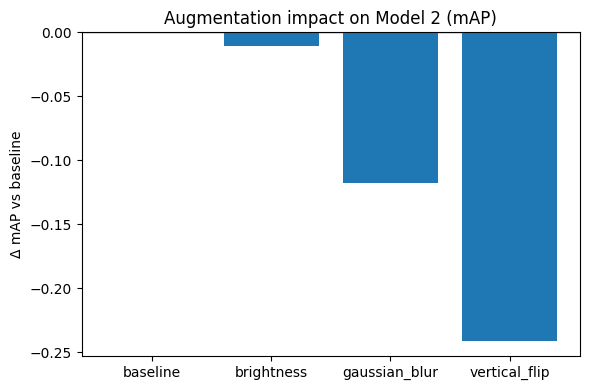

In [19]:

plt.figure(figsize=(6,4))
plt.bar(summary_df["condition"], summary_df["delta_mAP_vs_baseline"])
plt.axhline(0, linewidth=1)
plt.ylabel("Δ mAP vs baseline")
plt.title("Augmentation impact on Model 2 (mAP)")
plt.tight_layout()
plt.show()


## 8) Per-class impact table
Shows which classes degrade most under each augmentation.

In [26]:

# Build per-class delta tables
base_ap = base.ap_per_class
per_class = pd.DataFrame({"class_id": range(NUM_CLASSES), "class_name": CLASS_NAMES, "AP_baseline": base_ap})

for r in results:
    if r.condition == "baseline":
        continue
    per_class[f"AP_{r.condition}"] = r.ap_per_class
    per_class[f"delta_{r.condition}"] = r.ap_per_class - base_ap

display(per_class.sort_values("AP_baseline", ascending=False).head(20))

# Worst drops for each augmentation
for cond in ["gaussian_blur", "vertical_flip", "brightness"]:
    col = f"delta_{cond}"
    print(f"\nWorst AP drops for {cond}:")
    display(per_class.sort_values(col, ascending=True).head(10)[["class_name", "AP_baseline", col]])


,class_id,class_name,AP_baseline,AP_gaussian_blur,delta_gaussian_blur,AP_vertical_flip,delta_vertical_flip,AP_brightness,delta_brightness
18,18,van,0.794675,0.546830,-0.247845,0.254071,-0.540604,0.786516,-0.008159
17,17,truck,0.752615,0.519608,-0.233007,0.510479,-0.242136,0.675851,-0.076763
11,11,qr code,0.752381,0.672789,-0.079592,0.760220,0.007839,0.762410,0.010029
2,2,cardboard box,0.741048,0.670900,-0.070148,0.664047,-0.077001,0.738902,-0.002146
16,16,traffic light,0.720374,0.642097,-0.078277,0.718369,-0.002005,0.721548,0.001174
4,4,forklift,0.710022,0.546824,-0.163198,0.075326,-0.634696,0.711765,0.001744
15,15,traffic cone,0.700006,0.542734,-0.157272,0.109902,-0.590103,0.622187,-0.077819
6,6,gloves,0.640036,0.550341,-0.089695,0.091945,-0.548091,0.640052,0.000015
1,1,car,0.625435,0.467961,-0.157475,0.164696,-0.460739,0.624919,-0.000517
0,0,barcode,0.613418,0.446375,-0.167043,0.516942,-0.096476,0.609205,-0.004213



Worst AP drops for gaussian_blur:


,class_name,AP_baseline,delta_gaussian_blur
7,helmet,0.459277,-0.248134
18,van,0.794675,-0.247845
17,truck,0.752615,-0.233007
0,barcode,0.613418,-0.167043
4,forklift,0.710022,-0.163198
13,safety vest,0.527360,-0.158154
1,car,0.625435,-0.157475
15,traffic cone,0.700006,-0.157272
8,ladder,0.326845,-0.137426
10,person,0.502297,-0.130132



Worst AP drops for vertical_flip:


,class_name,AP_baseline,delta_vertical_flip
4,forklift,0.710022,-0.634696
15,traffic cone,0.700006,-0.590103
6,gloves,0.640036,-0.548091
18,van,0.794675,-0.540604
1,car,0.625435,-0.460739
13,safety vest,0.527360,-0.341132
7,helmet,0.459277,-0.321115
14,smoke,0.387013,-0.313395
17,truck,0.752615,-0.242136
10,person,0.502297,-0.220737



Worst AP drops for brightness:


,class_name,AP_baseline,delta_brightness
15,traffic cone,0.700006,-0.077819
17,truck,0.752615,-0.076763
7,helmet,0.459277,-0.053142
13,safety vest,0.527360,-0.009575
18,van,0.794675,-0.008159
12,road sign,0.187313,-0.006858
0,barcode,0.613418,-0.004213
9,license plate,0.364457,-0.003737
2,cardboard box,0.741048,-0.002146
10,person,0.502297,-0.000541
